O presente trabalho foi desenvolvido a partir de

Inciando através da cinemática diretea, onde buscamos a partir das variáveis do robô encontrar sua posição final.

In [ ]:
import sys
# O '../' faz o Python subir um nível de pasta
sys.path.append('../') 

%load_ext autoreload
%autoreload 2

import DH
import numpy as np
import sympy as sp

Construindo o Mecanismo

In [2]:
Planar_2R = [
    {'type': 'revolute', 'a':10, 'alpha': 0, 'd': 0,
     'errors': {'sigma': 0, 'beta': 0, 'epsilon': 0, 'phi': 0,}},

    {'type': 'revolute', 'a':30, 'alpha': 0, 'd': 0,
     'errors': {'sigma': 0, 'beta': 0, 'epsilon': 0, 'phi': 0,}}, 
]

robot = DH.Mechanism(Planar_2R)
# 1. Variáveis fixas
#Where the robot starts (in radians)
start_position = {
    robot.theta[0]: 0.0,
    robot.theta[1]: 0.0
}

# Variables to be used in forward kinematics and plotting
variable_values = {
    robot.theta[0]: (sp.pi/12),   # 15 degrees
    robot.theta[1]: (sp.pi/6),    # 30 degrees
}

# 2. Ranges de movimento
# Define que ambas as juntas podem dar uma volta completa (0 a 2*pi)
ranges_movimento = {
    robot.theta[0]: (0, 2*sp.pi),   
    robot.theta[1]: (0, 2*sp.pi),    
}

Observando o mecanismo exemplo

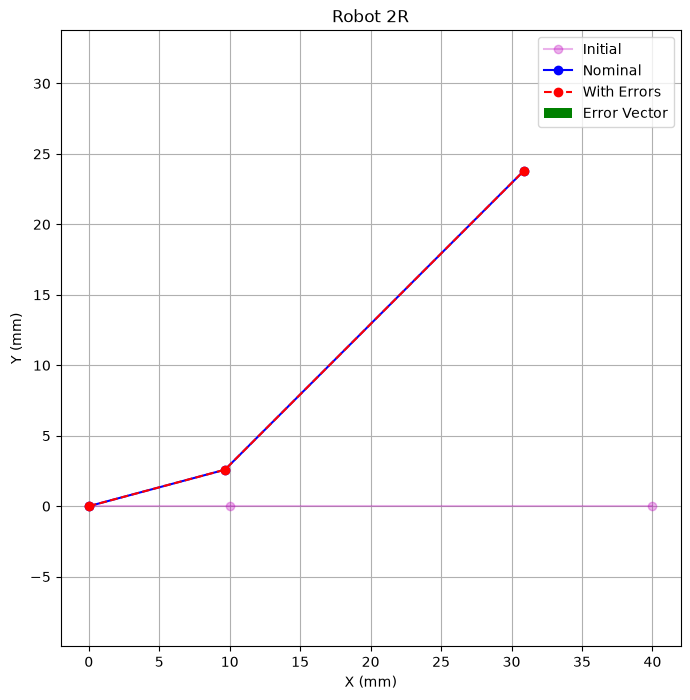

In [3]:
plotter = DH.MechanismPlotter(robot)
plotter.plot_mechanism(variable_values, title='Robot 2R', plot_type='2d')

A cinemática direta deste mecanismo em termos gerias é dada por:

In [4]:
matrix_g, position_g = robot.forward_kinematics(False)
matrix_g = sp.simplify(matrix_g)

matrix_g_numerical, position_g_numerical, orientation_g_numerical = robot.evaluate_param(matrix_g, variable_values)
print("\nFinal Position\n") 
print("\nPosition X:\n", position_g_numerical[0])
print("\nPosition y:\n", position_g_numerical[1])
print("\nPosition z:\n", position_g_numerical[2])


Final Position


Position X:
 30.872461698487108

Position y:
 23.801393886621632

Position z:
 0.0


In [5]:
plotter.simulate_movement(
    start_values=start_position, 
    end_values=variable_values, 
    frames=60,       # Mais quadros = vídeo mais suave
    interval=40,     # Tempo em ms entre os quadros (40ms = 25fps)
    plot_type='2d',
    title="Animação Cinemática Direta"
)

Entendendo seu espaço de trabalho

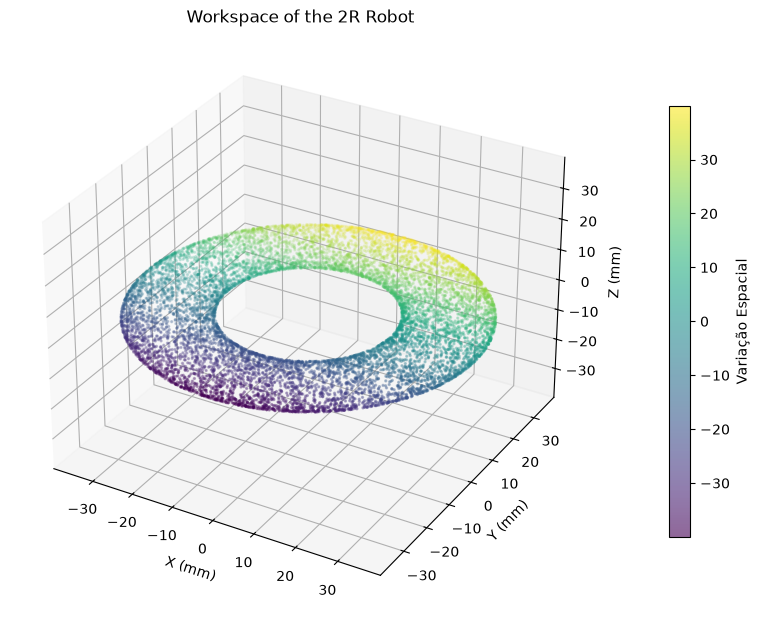

In [6]:
plotter.plot_workspace(
    joint_ranges=ranges_movimento, 
    num_samples=10000, 
    title='Workspace of the 2R Robot'
)

Cinemática Inversa

In [7]:
# Posição alvo (baseada na Cinemática Direta calculada anteriormente)
target_position = [40, 33, 0.0]

# Chamada da Cinemática Inversa
end_position = robot.inverse_kinematics(
    target_position=target_position, 
    initial_guess=start_position
)

print("\nResultados da Cinemática Inversa:")
for junta, valor in end_position.items():
    graus = np.degrees(valor) # Conversão correta usando NumPy
    print(f"{junta}: {valor:.4f} radianos ({graus:.2f} graus)")

Aviso: Alvo não alcançado com perfeição. O robô pode não ter graus de liberdade suficientes para esta posição+orientação. Erro de função de custo: 140.5545

Resultados da Cinemática Inversa:
theta_0: 0.6898 radianos (39.52 graus)
theta_1: 0.0000 radianos (0.00 graus)


Observando o movimento do robô 

In [8]:
plotter.simulate_movement(
    start_values=start_position, 
    end_values=end_position, 
    frames=60,       # Mais quadros = vídeo mais suave
    interval=40,     # Tempo em ms entre os quadros (40ms = 25fps)
    plot_type='2d',
    title="Animação Cinemática Inversa"
)